In [1]:
import os
import pandas as pd
from os.path import join as pjoin
from itertools import product

from catrace.dataset import load_dataset_config
dataset_name = 'juvenile'
dsconfig = load_dataset_config(f'../dataset_configs/{dataset_name}_dataset_t7.json')
capacity_dir = os.path.join(dsconfig.results_dir, 'capacity')
seed = 2345
N=700 # number of neurons
M=70 # number of data points

In [2]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [3]:
time_windows = [[17, 41], [25, 48], [32, 56], [40, 63], [47, 70], [55, 78], [62, 85], [70, 93], [77, 101], [85, 108]]

dfs = []
for window in time_windows:
    window_key = f'window_{window[0]}_{window[1]}'
    jobname = f'capacity_sweep_{window_key}_N{N}_M{M}_master_seed{seed}'
    input_dir = pjoin(capacity_dir, jobname)
    df_result_file = pjoin(input_dir, f'df_result.pkl')
    dfs.append(pd.read_pickle(df_result_file))


In [4]:
capdf = pd.concat(dfs)
capdf = capdf[capdf.index.get_level_values('shuffle') == False]
capdf.reset_index(level=['condition', 'window_0', 'window_1'], inplace=True)
capdf['start_time'] = (capdf['window_0'] / 7.5 - 2.3).round()
capdf['end_time'] = (capdf['window_1'] / 7.5 - 2.3).round()
capdf['middle_time'] = ((capdf['start_time'] + capdf['end_time']) / 2)

In [5]:
capdf['middle_time'].unique()

array([ 1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5])

In [6]:
capdf

condition  window_0  \
fish_id                   odor1 odor2 shuffle seed                        
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348      naive        17   
                          Phe   TCA   False   2350      naive        17   
                          GCA   Phe   False   2354      naive        17   
                          TCA   TDCA  False   2352      naive        17   
                          Arg   Phe   False   2357      naive        17   
...                                                       ...       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831   phe-trp        85   
                          Arg   GCA   False   48832   phe-trp        85   
                                TDCA  False   48835   phe-trp        85   
                          Phe   TDCA  False   48841   phe-trp        85   
                                Trp   False   48834   phe-trp        85   

                                                     window_1  capacity  \
fish_id                   odor1 odor2 shuffle seed                        
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348         41  0.135754   
                          Phe   TCA   False   2350         41  0.150162   
                          GCA   Phe   False   2354         41  0.147545   
                          TCA   TDCA  False   2352         41  0.139638   
                          Arg   Phe   False   2357         41  0.133974   
...                                                       ...       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831       108  0.177481   
                          Arg   GCA   False   48832       108  0.185095   
                                TDCA  False   48835       108  0.176935   
                          Phe   TDCA  False   48841       108  0.164581   
                                Trp   False   48834       108  0.146649   

                                                     dimension    radius  \
fish_id                   odor1 odor2 shuffle seed                         
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348   11.284751  1.015865   
                          Phe   TCA   False   2350   10.695328  0.983740   
                          GCA   Phe   False   2354   10.751084  0.979625   
                          TCA   TDCA  False   2352   11.064841  1.006009   
                          Arg   Phe   False   2357   11.503750  1.030167   
...                                                        ...       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831   9.758912  0.936569   
                          Arg   GCA   False   48832   9.401332  0.941465   
                                TDCA  False   48835   9.535739  0.943998   
                          Phe   TDCA  False   48841  10.205505  0.960427   
                                Trp   False   48834  10.664492  1.042992   

                                                      utility  \
fish_id                   odor1 odor2 shuffle seed              
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348   0.778029   
                          Phe   TCA   False   2350   0.789854   
                          GCA   Phe   False   2354   0.776812   
                          TCA   TDCA  False   2352   0.777167   
                          Arg   Phe   False   2357   0.793497   
...                                                       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831  0.809340   
                          Arg   GCA   False   48832  0.817653   
                                TDCA  False   48835  0.795040   
                          Phe   TDCA  False   48841  0.805924   
                                Trp   False   48834  0.814865   

                                                     center_alignment  \
fish_id                   odor1 odor2 shuffle seed                      
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348           0.814240   
                          Phe   TCA   False   

In [ ]:
# window in frames to window in seconds: (window / 7.5 - 2.3).round()
capdf['start_time'] = (capdf['window_0'] / 7.5 - 2.3)
capdf['end_time'] = (capdf['window_1'] / 7.5 - 2.3)

capdf_to_save = capdf[['condition', 'window_0', 'window_1', 'start_time', 'end_time', 'capacity']]

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'figure05')
os.makedirs(save_dir, exist_ok=True)
capdf_to_save.to_csv(os.path.join(save_dir, f'figure05d_juvenile_capacity_timecourse.csv'))

capdf_geom_to_save = capdf[['condition', 'window_0', 'window_1', 'start_time', 'end_time', 'radius', 'dimension', 'center_alignment', 'axis_alignment']]
save_dir = os.path.join(figure_data_dir, 'extended_figure07')
os.makedirs(save_dir, exist_ok=True)
capdf_geom_to_save.to_csv(os.path.join(save_dir, f'extended_figure07e_juvenile_geometric_measures_timecourse.csv'))

Text(0, 0.5, 'Capacity')

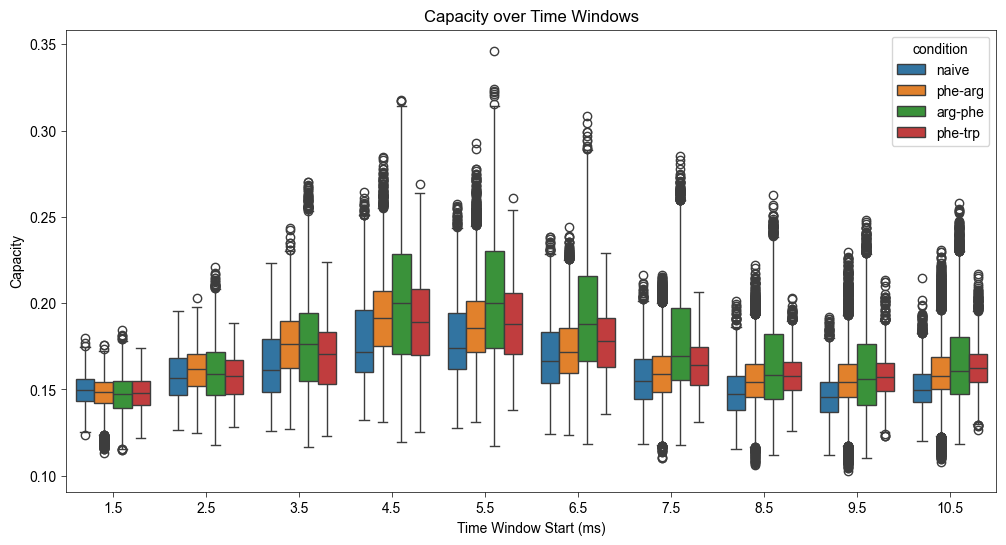

In [8]:

# Plot boxplot with window_0 as x, capacity as y, and condition as hue
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=capdf, x='middle_time', y='capacity', hue='condition', ax=ax)
ax.set_title('Capacity over Time Windows')
ax.set_xlabel('Time Window Start (ms)')
ax.set_ylabel('Capacity')

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_measure_over_time_windows(capdf, measure='capacity', window_col='middle_time', hue_col='condition', errorbar='se', figsize=(5, 3.5), sns_params=None):
    """
    Plot a measure (e.g., capacity) over time windows with conditions as hue.
    
    Parameters:
    - capdf: DataFrame containing the data.
    - measure: The measure to plot (default is 'capacity').
    - window_col: Column name for the time window (default is 'window_0').
    - hue_col: Column name for the condition (default is 'condition').
    - figsize: Tuple specifying the figure size (default is (5, 3.5)).
    """
    fig, ax = plt.subplots(figsize=figsize)
    color_dict = {'naive': 'tab:blue', 
                'arg-phe': 'salmon',
                'phe-arg': 'm',
                'phe-trp': 'tab:green',
    }
    if sns_params is None:
        sns_params = {}
    sns.lineplot(
        data=capdf.sort_values(window_col),
        x=window_col, y=measure, hue=hue_col,
        estimator='mean',      # aggregate by mean at each (window_0, condition)
        errorbar=errorbar,         # shaded band = standard deviation
        marker='o',            # optional: markers at means
        ax=ax,
        palette=color_dict,   # use custom color palette
        **sns_params           # pass additional sns parameters (e.g., markersize)
    )
    ax.set_title(f'{measure.capitalize()} over Time Windows')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(measure.capitalize())
    ax.legend(title=hue_col)
    plt.tight_layout()
    return fig, ax


In [ ]:
paper_fig_dir = '../../figures_for_paper/juvenile/capacity/timecourse'
os.makedirs(paper_fig_dir, exist_ok=True)

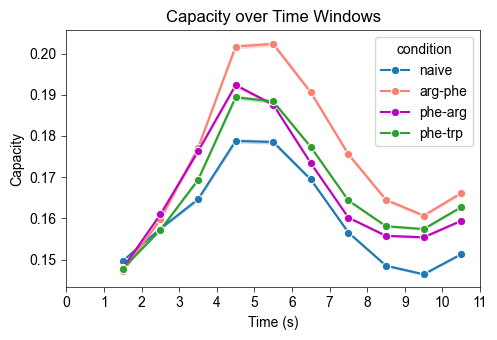

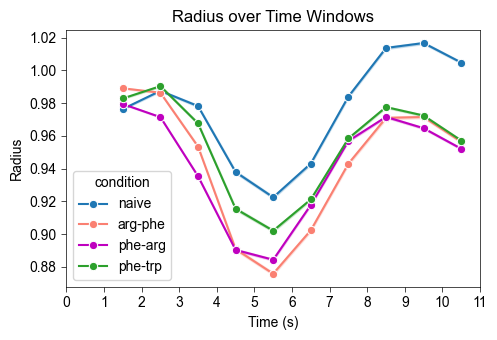

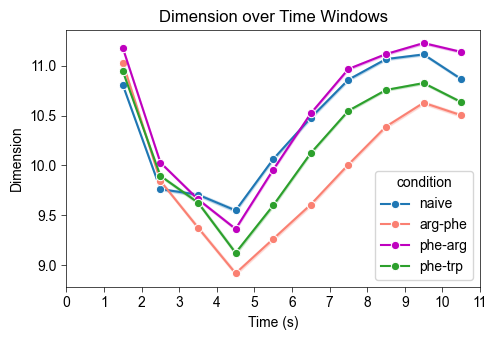

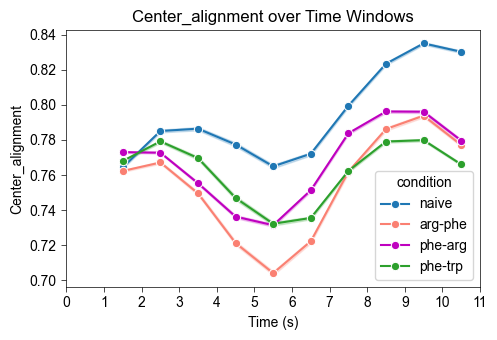

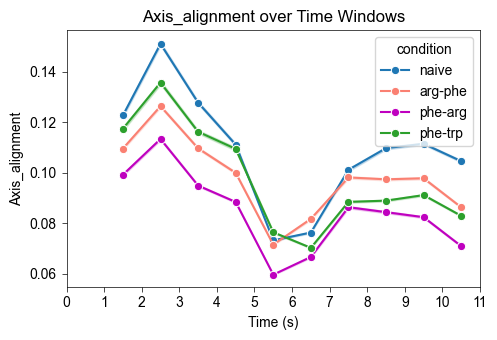

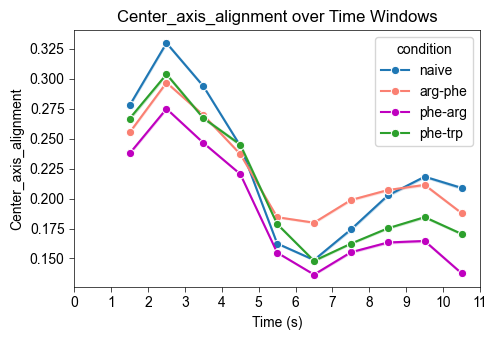

In [11]:

for measure in ['capacity', 'radius', 'dimension', 'center_alignment', 'axis_alignment', 'center_axis_alignment']:
    fig, ax = plot_measure_over_time_windows(capdf, measure=measure, window_col='middle_time', hue_col='condition')
    # Set x lim
    ax.set_xlim((0,11))
    # Set x axis interval
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(1))
    # Save figure
    fig_name = f'{measure}_timecourse.pdf'
    fig_path = pjoin(paper_fig_dir, fig_name)
    fig.savefig(fig_path)
    

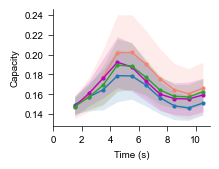

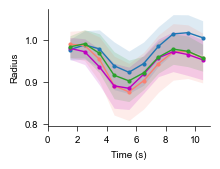

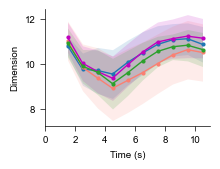

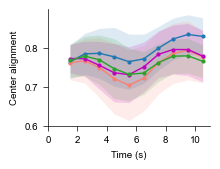

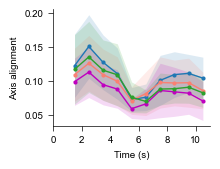

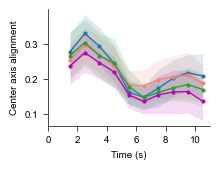

In [12]:
measures = ['capacity', 'radius', 'dimension', 'center_alignment', 'axis_alignment', 'center_axis_alignment']
ytick_intervals = [0.02, None, None, None, None, None]
for measure in measures:
    figsize=(2.3,2.0)
    # Decrease marker size in sns.lineplot by passing sns_params
    # linewidth = 1
    # Also remove the white edge around markers by setting markeredgewidth to 0
    sns_params = {'markersize': 3,
                  'linewidth': 1,
                  'markeredgewidth': 0,
                   # Set the std shading with alpha = 0.3, only for the shading of the standard deviation area, not the markers, not the lines
                   'err_kws': {'alpha': 0.15,
                               "linewidth": 0}}
    fig, ax = plot_measure_over_time_windows(capdf, measure=measure, window_col='middle_time', hue_col='condition', errorbar='sd', figsize=figsize,
                                             sns_params=sns_params)
    ax.set_xlim((0,11))
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(1))
    sns.despine()
    # Set xlabel, ylabel, tick fontsize to 7
    ax.set_xlabel('Time (s)', fontsize=7)
    ylabel = measure.replace('_', ' ').capitalize()
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(axis='both', which='major', labelsize=7)
    # Set x tick interval to 2
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ytick_interval = ytick_intervals[measures.index(measure)]
    if ytick_interval is not None:
        ax.yaxis.set_major_locator(MultipleLocator(ytick_interval))
    plt.tight_layout()
    # Remove legend
    ax.legend_.remove()
    # Remove title
    ax.set_title('')
    # Save figure
    fig_name = f'{measure}_timecourse_with_std.pdf'
    fig_path = pjoin(paper_fig_dir, fig_name)
    fig.savefig(fig_path)


In [13]:
capdf

condition  window_0  \
fish_id                   odor1 odor2 shuffle seed                        
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348      naive        17   
                          Phe   TCA   False   2350      naive        17   
                          GCA   Phe   False   2354      naive        17   
                          TCA   TDCA  False   2352      naive        17   
                          Arg   Phe   False   2357      naive        17   
...                                                       ...       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831   phe-trp        85   
                          Arg   GCA   False   48832   phe-trp        85   
                                TDCA  False   48835   phe-trp        85   
                          Phe   TDCA  False   48841   phe-trp        85   
                                Trp   False   48834   phe-trp        85   

                                                     window_1  capacity  \
fish_id                   odor1 odor2 shuffle seed                        
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348         41  0.135754   
                          Phe   TCA   False   2350         41  0.150162   
                          GCA   Phe   False   2354         41  0.147545   
                          TCA   TDCA  False   2352         41  0.139638   
                          Arg   Phe   False   2357         41  0.133974   
...                                                       ...       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831       108  0.177481   
                          Arg   GCA   False   48832       108  0.185095   
                                TDCA  False   48835       108  0.176935   
                          Phe   TDCA  False   48841       108  0.164581   
                                Trp   False   48834       108  0.146649   

                                                     dimension    radius  \
fish_id                   odor1 odor2 shuffle seed                         
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348   11.284751  1.015865   
                          Phe   TCA   False   2350   10.695328  0.983740   
                          GCA   Phe   False   2354   10.751084  0.979625   
                          TCA   TDCA  False   2352   11.064841  1.006009   
                          Arg   Phe   False   2357   11.503750  1.030167   
...                                                        ...       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831   9.758912  0.936569   
                          Arg   GCA   False   48832   9.401332  0.941465   
                                TDCA  False   48835   9.535739  0.943998   
                          Phe   TDCA  False   48841  10.205505  0.960427   
                                Trp   False   48834  10.664492  1.042992   

                                                      utility  \
fish_id                   odor1 odor2 shuffle seed              
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348   0.778029   
                          Phe   TCA   False   2350   0.789854   
                          GCA   Phe   False   2354   0.776812   
                          TCA   TDCA  False   2352   0.777167   
                          Arg   Phe   False   2357   0.793497   
...                                                       ...   
2021-11-26-DpOBEM-JH24_Dp Phe   TCA   False   48831  0.809340   
                          Arg   GCA   False   48832  0.817653   
                                TDCA  False   48835  0.795040   
                          Phe   TDCA  False   48841  0.805924   
                                Trp   False   48834  0.814865   

                                                     center_alignment  \
fish_id                   odor1 odor2 shuffle seed                      
2021-07-15-DpOBEM-N2_Dp   GCA   TCA   False   2348           0.814240   
                          Phe   TCA   False   